<div align="center">

<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>

<img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg"
     alt="Python" width="80" height="80"/>

<h1 align="center">Bibliotecas Fundamentais de Python</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3.11-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-2.x-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>

<br>

<h1 style="font-size:2em; margin: 4px 0;">Projeto Integrador: Trocador de Calor Industrial</h1>

<p style="font-size:13px; opacity:0.6; margin-top:6px;"><em>Análise exploratória e modelagem preditiva de eficiência com NumPy</em></p>

<br>

</div>

---

## Contexto do Problema

Um **trocador de calor industrial** monitora diariamente variáveis como temperatura de entrada/saída da água e do glicol. A métrica de interesse é a **eficiência térmica**.

Ao longo do tempo de operação, o equipamento sofre desgaste gradual e a eficiência tende a **decair monotonicamente**. Este relatório cobre:

1. Carregamento do dataset ajustado (pré-processado na aula de Pandas)
2. Análise exploratória das variáveis
3. Modelagem de regressão linear com **NumPy**
4. Resposta a perguntas de negócio sobre o desempenho futuro do equipamento

---

## <span style="color:#1E90FF;">1. Importações</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')

---
## <span style="color:#1E90FF;">2. Carregamento do Dataset Ajustado</span>

O arquivo `heat_exchanger_processado.csv` foi gerado na aula de **Pandas**: valores ausentes foram tratados por interpolação linear e novas colunas derivadas foram adicionadas (`mes`, `dia_semana`, `delta_glicol`).

In [2]:
df = pd.read_csv('data/heat_exchanger_processado.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# dia de operação: 0 = primeiro registro histórico
df['dia_op'] = range(len(df))

print('Shape:', df.shape)
print('Período:', df['timestamp'].iloc[0].date(), '→', df['timestamp'].iloc[-1].date())
df.head()

Shape: (175, 10)
Período: 2025-09-29 → 2026-03-28


,timestamp,t_water_in,t_glycol_int,t_glycol_out,t_water_out,efficiency,mes,dia_semana,delta_glicol,dia_op
0,2025-09-29,33.49,85.82,46.50,61.808856,96.454517,9,Monday,39.32,0
1,2025-09-30,33.51,86.35,46.75,61.894941,96.432576,9,Tuesday,39.60,1
2,2025-10-01,33.39,85.98,46.55,61.672872,96.410674,10,Wednesday,39.43,2
3,2025-10-02,33.32,85.71,46.51,61.403079,96.388810,10,Thursday,39.20,3
4,2025-10-03,32.86,87.54,46.71,61.583481,96.366986,10,Friday,40.83,4


---
## <span style="color:#1E90FF;">3. Análise Exploratória</span>

Antes de modelar, exploramos o comportamento de **todas as variáveis** do dataset:

| Variável | Descrição |
|---|---|
| `t_water_in` | Temperatura de entrada da água (°C) |
| `t_glycol_int` | Temperatura de entrada do glicol (°C) |
| `t_glycol_out` | Temperatura de saída do glicol (°C) |
| `t_water_out` | Temperatura de saída da água (°C) |
| `efficiency` | Eficiência térmica do trocador (%) |
| `delta_glicol` | Diferença de temperatura do glicol: entrada − saída (°C) |

In [3]:
numericas = ['t_water_in', 't_glycol_int', 't_glycol_out', 't_water_out', 'efficiency', 'delta_glicol']
df[numericas].describe().round(3)

,t_water_in,t_glycol_int,t_glycol_out,t_water_out,efficiency,delta_glicol
count,175.000,175.000,175.000,175.000,175.000,175.000
mean,31.442,69.691,41.342,51.468,94.742,28.349
std,2.382,24.795,7.686,13.867,0.941,17.257
min,20.850,21.110,20.700,21.263,93.225,-2.710
25%,30.910,31.545,31.565,33.129,93.922,3.360
50%,32.100,84.130,45.580,59.251,94.692,38.030
75%,32.770,85.845,46.485,60.107,95.536,39.590
max,35.930,89.180,48.970,64.061,96.455,44.140


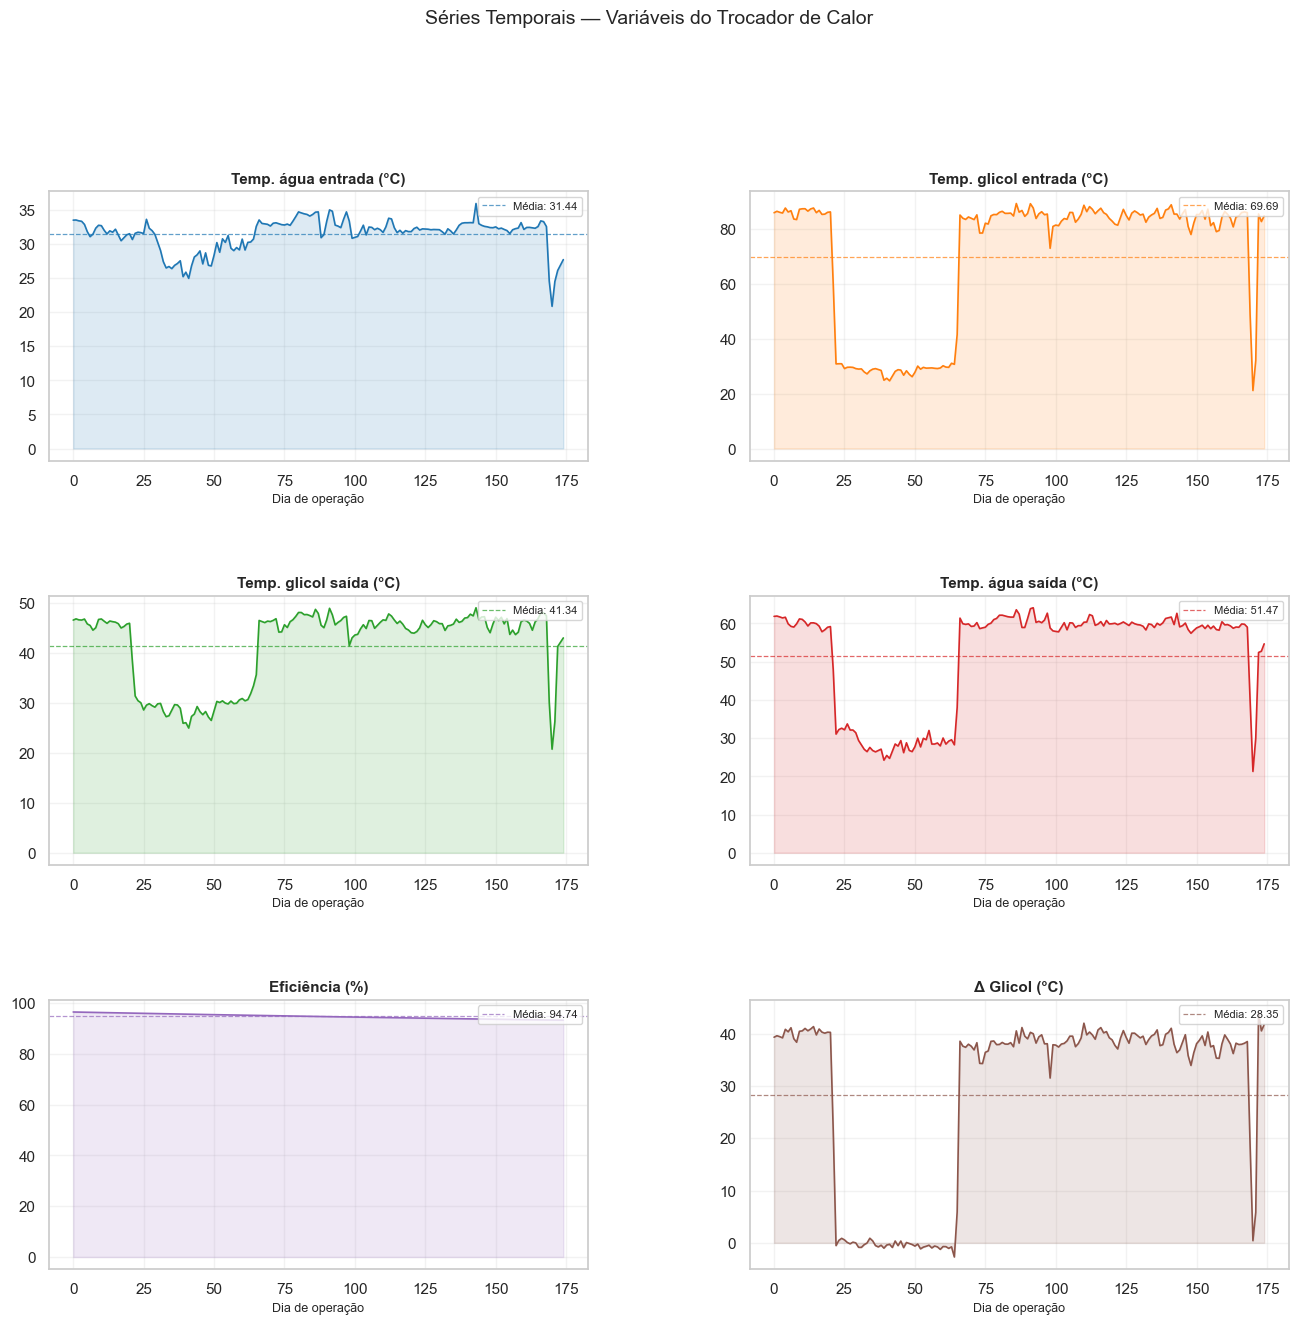

In [4]:
# --- 3.1 Séries Temporais — todas as variáveis ---
import matplotlib.gridspec as gridspec

variaveis = ['t_water_in', 't_glycol_int', 't_glycol_out', 't_water_out', 'efficiency', 'delta_glicol']
titulos   = ['Temp. água entrada (°C)', 'Temp. glicol entrada (°C)', 'Temp. glicol saída (°C)',
             'Temp. água saída (°C)',   'Eficiência (%)',             'Δ Glicol (°C)']
cmap  = plt.colormaps['tab10']
cores = [cmap(i) for i in range(len(variaveis))]

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)

for i, (var, titulo, cor) in enumerate(zip(variaveis, titulos, cores)):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    ax.plot(df['dia_op'], df[var], color=cor, linewidth=1.2)
    ax.fill_between(df['dia_op'], df[var], alpha=0.15, color=cor)

    # linha de média
    media = df[var].mean()
    ax.axhline(media, color=cor, linestyle='--', linewidth=0.9, alpha=0.7,
               label=f'Média: {media:.2f}')

    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dia de operação', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.25)

fig.suptitle('Séries Temporais — Variáveis do Trocador de Calor', fontsize=14, y=1.01)
plt.show()

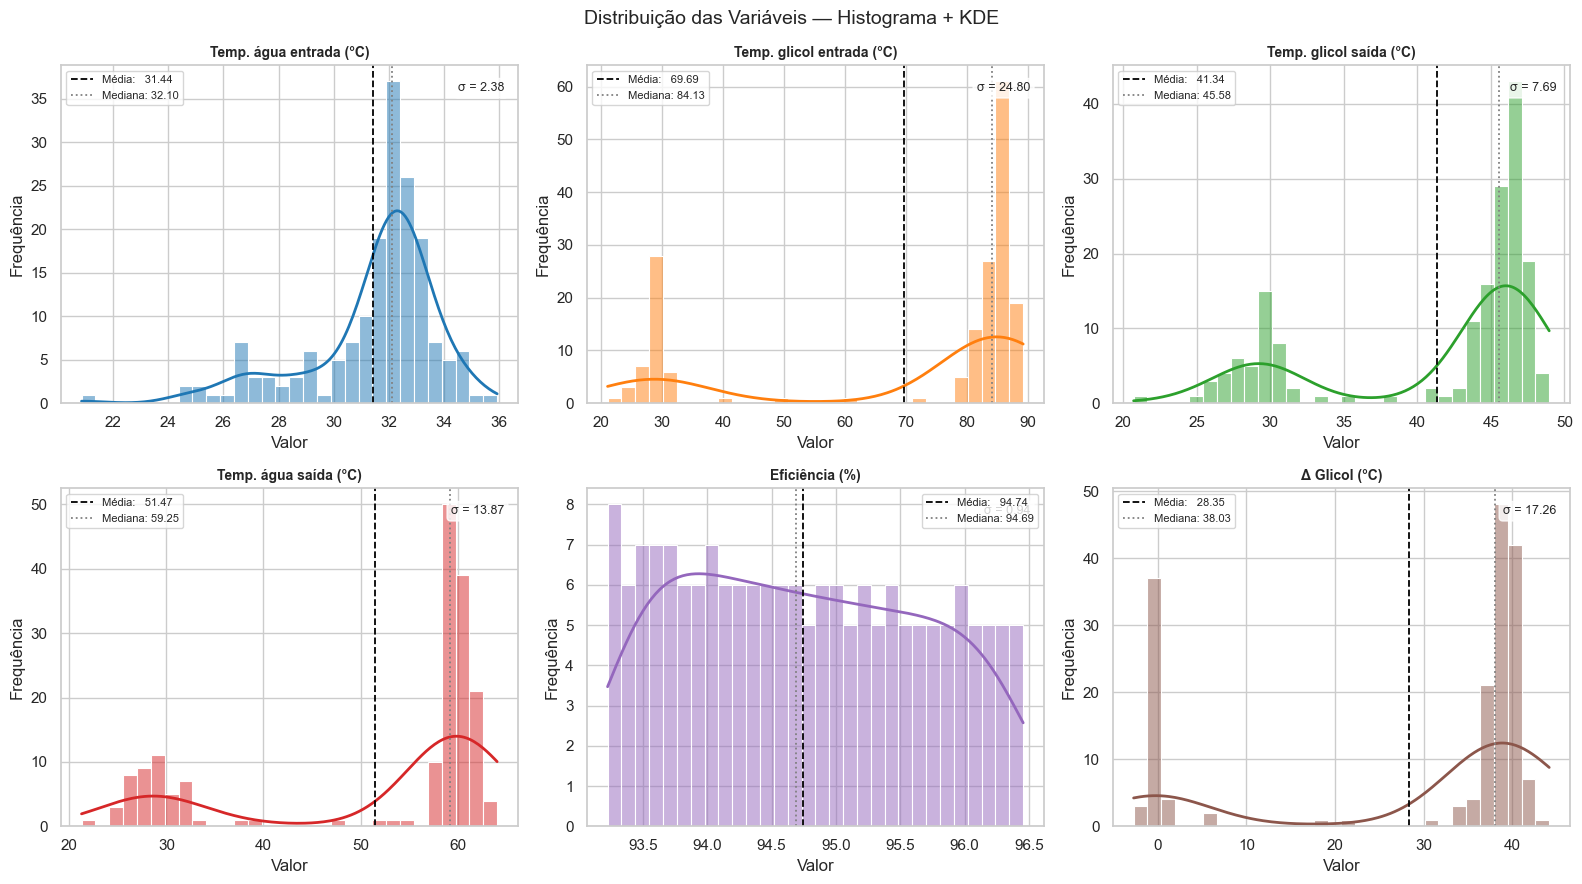

In [5]:
# --- 3.2 Distribuições — sns.histplot com KDE sobreposto ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuição das Variáveis — Histograma + KDE', fontsize=14)

for ax, var, titulo, cor in zip(axes.flat, variaveis, titulos, cores):
    sns.histplot(df[var], bins=30, color=cor, ax=ax, kde=True,
                 line_kws={'linewidth': 2})

    media   = df[var].mean()
    mediana = df[var].median()
    desvio  = df[var].std()

    ax.axvline(media,   color='black', linestyle='--', linewidth=1.3, label=f'Média:   {media:.2f}')
    ax.axvline(mediana, color='gray',  linestyle=':',  linewidth=1.3, label=f'Mediana: {mediana:.2f}')
    ax.text(0.97, 0.95, f'σ = {desvio:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/yp/cbz_mzxs6bz3xnpkml_fqr_h0000gn/T/ipykernel_91723/3695915237.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Eficiência (%) / Δ Glicol (°C)'])


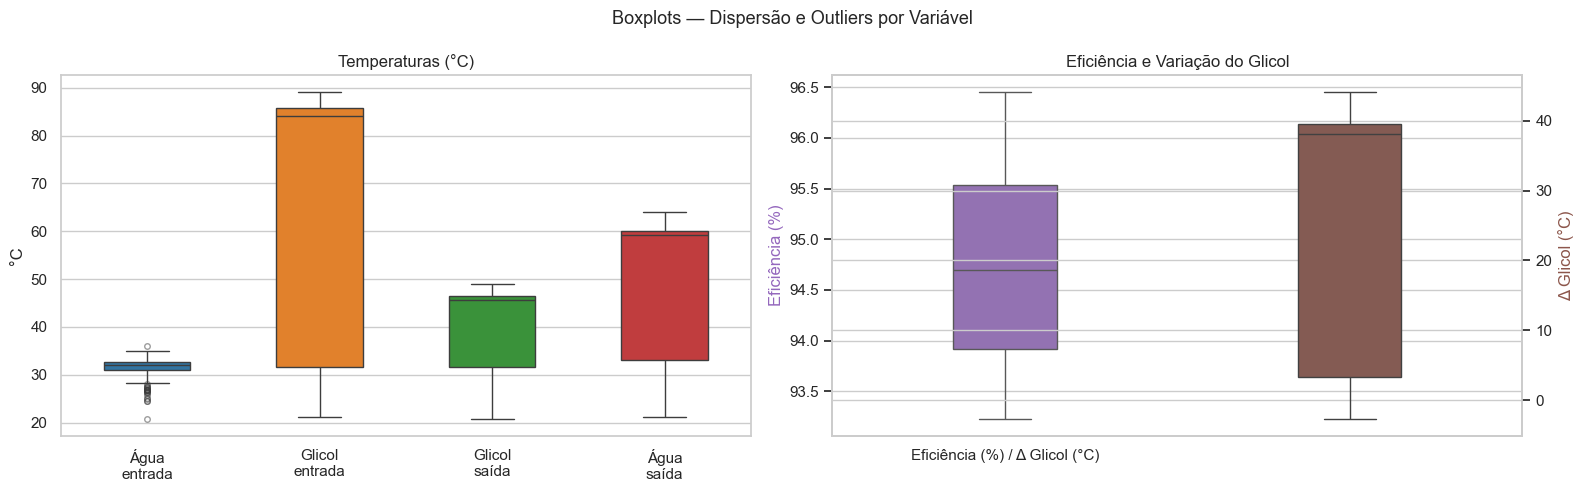

In [6]:
# --- 3.3 Boxplot — sns.boxplot em dois painéis por escala ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Boxplots — Dispersão e Outliers por Variável', fontsize=13)

# painel esquerdo: temperaturas (escala compatível)
df_temps = df[['t_water_in', 't_glycol_int', 't_glycol_out', 't_water_out']].copy()
df_temps.columns = ['Água\nentrada', 'Glicol\nentrada', 'Glicol\nsaída', 'Água\nsaída']
sns.boxplot(data=df_temps, ax=axes[0], palette=cores[:4], width=0.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Temperaturas (°C)')
axes[0].set_ylabel('°C')

# painel direito: eficiência e delta glicol (escalas distintas — twin axis)
ax2 = axes[1]
ax2b = ax2.twinx()

sns.boxplot(data=df[['efficiency']], ax=ax2, palette=[cores[4]], width=0.3,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
sns.boxplot(data=df[['delta_glicol']], ax=ax2b, palette=[cores[5]], width=0.3,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))

ax2.set_ylabel('Eficiência (%)', color=cores[4])
ax2b.set_ylabel('Δ Glicol (°C)', color=cores[5])
ax2.set_xticklabels(['Eficiência (%) / Δ Glicol (°C)'])
ax2.set_title('Eficiência e Variação do Glicol')

plt.tight_layout()
plt.show()

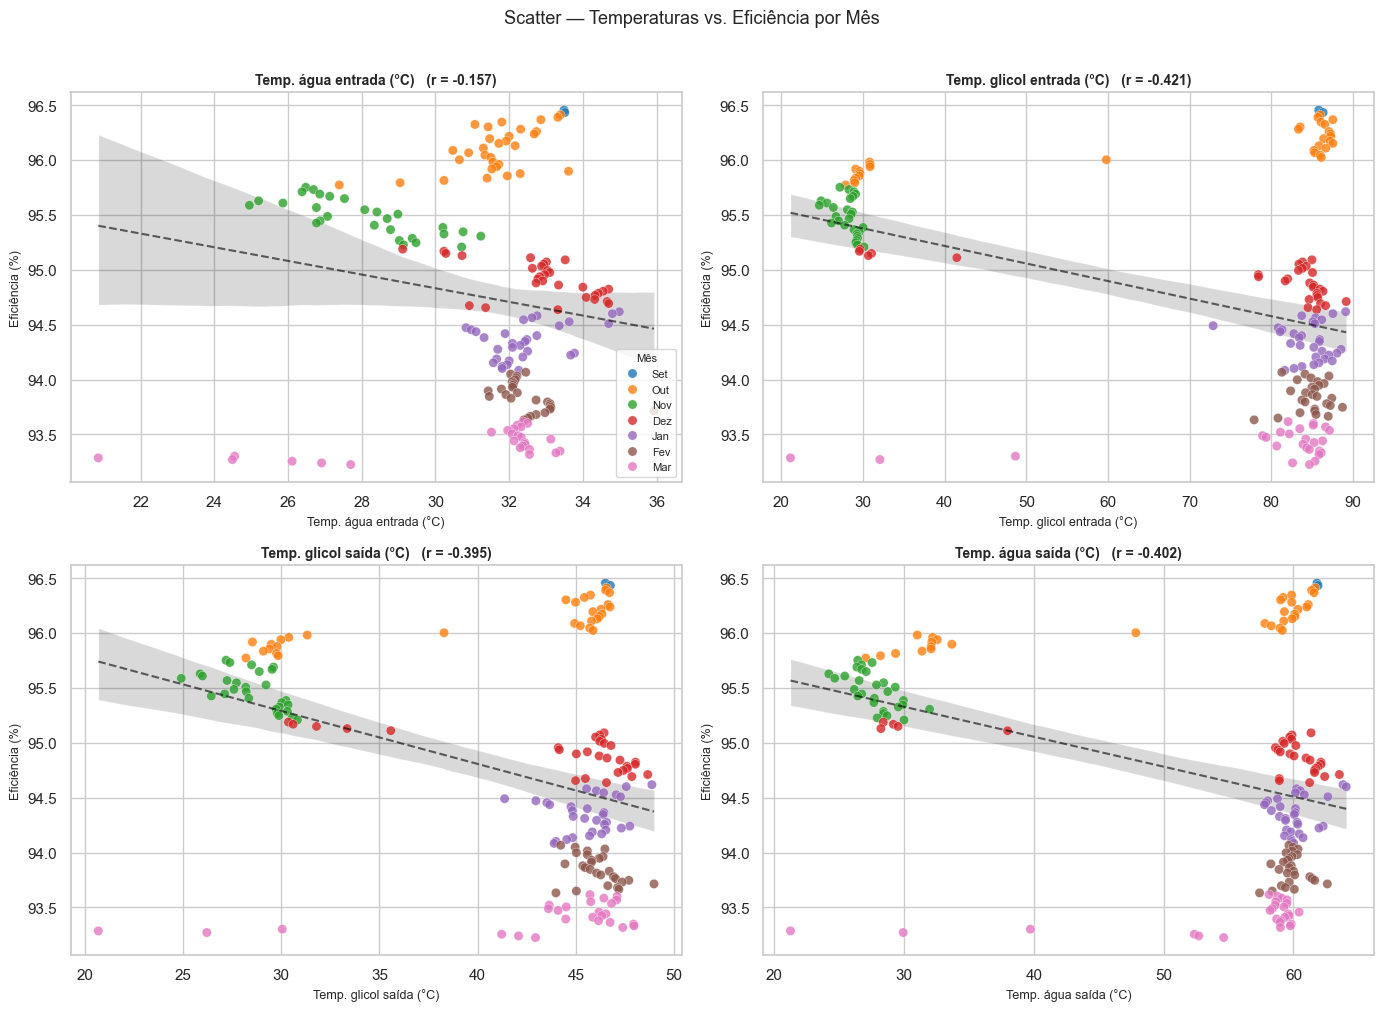

In [7]:
# --- 3.4 Scatter — sns.scatterplot por mês + linha de tendência (sns.regplot) ---
pares = [
    ('t_water_in',   'Temp. água entrada (°C)'),
    ('t_glycol_int', 'Temp. glicol entrada (°C)'),
    ('t_glycol_out', 'Temp. glicol saída (°C)'),
    ('t_water_out',  'Temp. água saída (°C)'),
]

nomes_mes = {9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez', 1: 'Jan', 2: 'Fev', 3: 'Mar'}
df['mes_nome'] = df['mes'].map(nomes_mes)
ordem_mes = ['Set', 'Out', 'Nov', 'Dez', 'Jan', 'Fev', 'Mar']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scatter — Temperaturas vs. Eficiência por Mês', fontsize=13, y=1.01)

for ax, (var, label) in zip(axes.flat, pares):
    # reta de regressão geral com intervalo de confiança
    sns.regplot(data=df, x=var, y='efficiency', ax=ax, scatter=False,
                line_kws={'color': 'black', 'linewidth': 1.5, 'linestyle': '--', 'alpha': 0.6},
                ci=95)

    # pontos coloridos por mês
    sns.scatterplot(data=df, x=var, y='efficiency', hue='mes_nome',
                    hue_order=ordem_mes, palette='tab10',
                    s=45, alpha=0.8, edgecolor='white', linewidth=0.3, ax=ax)

    r = np.corrcoef(df[var].values, df['efficiency'].values)[0, 1]
    ax.set_title(f'{label}   (r = {r:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Eficiência (%)', fontsize=9)

    # legenda compacta apenas no primeiro subplot
    if ax is axes[0, 0]:
        ax.legend(title='Mês', fontsize=8, title_fontsize=8,
                  loc='lower right', framealpha=0.8)
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

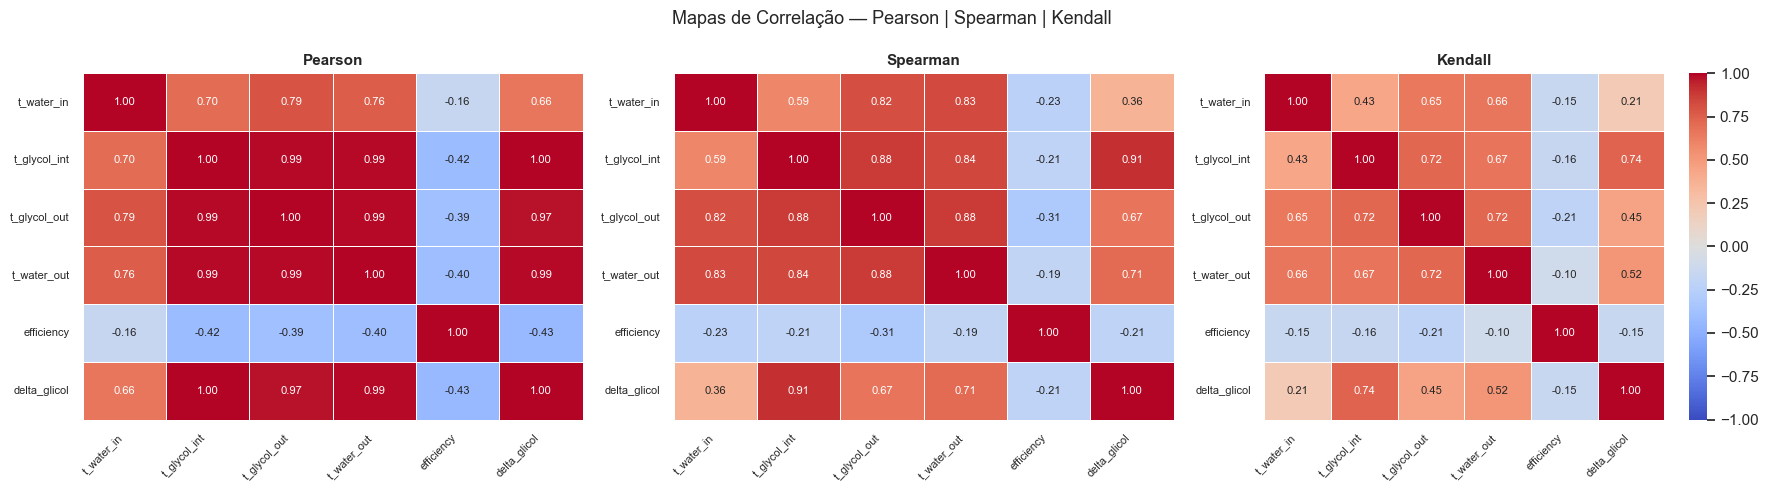

In [8]:
# --- 3.5 Heatmap de correlação — três métodos comparados ---
#
# method='pearson'  → correlação LINEAR entre variáveis contínuas.
#                     Pressupõe distribuição aproximadamente normal e relação proporcional.
#                     Sensível a outliers. Mede: cov(X,Y) / (σX · σY). Intervalo: [-1, 1].
#
# method='spearman' → correlação de POSTOS (ranks). Mede relações MONOTÔNICAS
#                     (não necessariamente lineares). Robusta a outliers.
#                     Equivale ao Pearson aplicado sobre os ranks de X e Y.
#
# method='kendall'  → correlação de CONCORDÂNCIA (tau de Kendall). Conta pares
#                     concordantes e discordantes. Mais robusta em amostras pequenas
#                     e quando há muitos empates. Interpretação: prob(concordância) − prob(discordância).

metodos = ['pearson', 'spearman', 'kendall']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mapas de Correlação — Pearson | Spearman | Kendall', fontsize=13)

for ax, method in zip(axes, metodos):
    corr = df[numericas].corr(method=method).round(2)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
                annot_kws={'size': 8}, ax=ax, cbar=(method == 'kendall'))
    ax.set_title(method.capitalize(), fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">4. Modelagem com NumPy: Regressão Linear</span>

A eficiência apresenta decaimento aproximadamente **linear** com o dia de operação. Ajustamos o modelo:

$$\hat{\eta}(d) = a + b \cdot d$$

onde $d$ é o dia de operação, $a$ é o intercepto e $b$ é a taxa de decaimento diário.  
Os coeficientes são obtidos pelo **Método dos Mínimos Quadrados (OLS)**:

$$b = \frac{\sum_{i=1}^{n}(d_i - \bar{d})(\eta_i - \bar{\eta})}{\sum_{i=1}^{n}(d_i - \bar{d})^2}, \qquad a = \bar{\eta} - b\,\bar{d}$$

O NumPy implementa este cálculo via `np.polyfit(x, y, grau)`.

In [9]:
x = df['dia_op'].values          # variável independente: dia de operação
y = df['efficiency'].values      # variável dependente: eficiência

# ajuste de polinômio de grau 1 (regressão linear)
coef = np.polyfit(x, y, 1)
b, a = coef[0], coef[1]          # slope e intercepto

# função polinomial para predição
modelo = np.poly1d(coef)

# métricas de ajuste
y_pred = modelo(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f'Intercepto (a):          {a:.6f} %')
print(f'Taxa de decaimento (b):  {b:.6f} %/dia')
print(f'R²:                      {r2:.6f}')

Intercepto (a):          96.356428 %
Taxa de decaimento (b):  -0.018559 %/dia
R²:                      0.997740


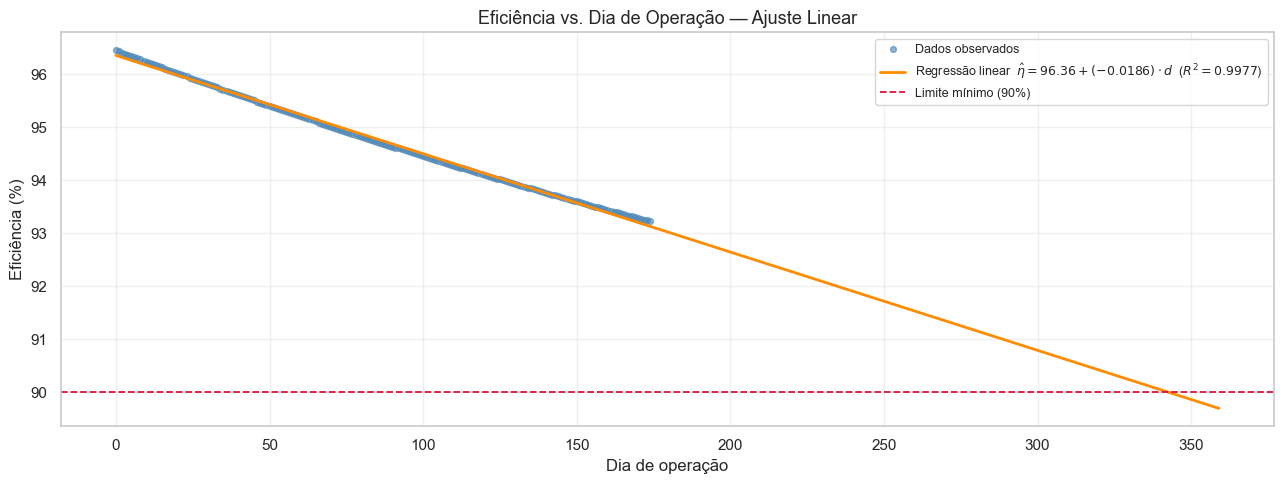

In [10]:
# eixo estendido até o dia 350 para visualizar extrapolação
x_ext = np.arange(0, 360)
y_ext = modelo(x_ext)

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(x, y, color='steelblue', s=18, alpha=0.6, label='Dados observados')
ax.plot(x_ext, y_ext, color='darkorange', linewidth=2,
        label=f'Regressão linear  $\hat{{\\eta}} = {a:.2f} + ({b:.4f}) \\cdot d$  ($R^2={r2:.4f}$)')
ax.axhline(90, color='crimson', linestyle='--', linewidth=1.3, label='Limite mínimo (90%)')

ax.set_title('Eficiência vs. Dia de Operação — Ajuste Linear', fontsize=13)
ax.set_xlabel('Dia de operação')
ax.set_ylabel('Eficiência (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">5. Respostas às Perguntas</span>

### Q1: Se o limite de eficiência permitido é 90%, em que momento o processo alcançará essa eficiência?

Invertendo o modelo linear:

$$d^* = \frac{\eta^* - a}{b}$$

onde $\eta^* = 90\%$.

  RESPOSTA — Q1
  Limite de eficiência:    90.0 %
  Dia estimado de alcance: dia 342.5
  Data correspondente:     2026-09-06


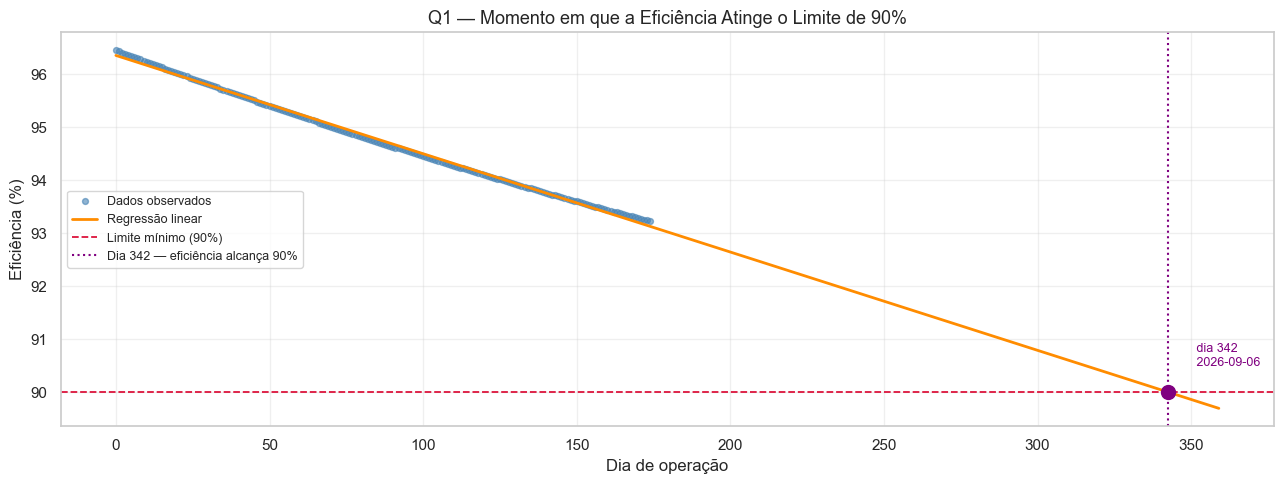

In [11]:
import datetime

eta_limite = 90.0
data_inicio = df['timestamp'].iloc[0]

# dia em que a eficiência estimada atinge o limite
dia_limite = (eta_limite - a) / b
data_limite = data_inicio + datetime.timedelta(days=int(np.round(dia_limite)))

print('=' * 52)
print('  RESPOSTA — Q1')
print('=' * 52)
print(f'  Limite de eficiência:    {eta_limite} %')
print(f'  Dia estimado de alcance: dia {dia_limite:.1f}')
print(f'  Data correspondente:     {data_limite.date()}')
print('=' * 52)

# visualização com destaque
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(x, y, color='steelblue', s=18, alpha=0.6, label='Dados observados')
ax.plot(x_ext, y_ext, color='darkorange', linewidth=2, label='Regressão linear')
ax.axhline(90, color='crimson', linestyle='--', linewidth=1.3, label='Limite mínimo (90%)')
ax.axvline(dia_limite, color='purple', linestyle=':', linewidth=1.5,
           label=f'Dia {dia_limite:.0f} — eficiência alcança 90%')
ax.plot(dia_limite, 90, 'o', color='purple', markersize=10, zorder=5)
ax.annotate(f' dia {dia_limite:.0f}\n {data_limite.date()}',
            xy=(dia_limite, 90), xytext=(dia_limite + 8, 90.5),
            fontsize=9, color='purple')

ax.set_title('Q1 — Momento em que a Eficiência Atinge o Limite de 90%', fontsize=13)
ax.set_xlabel('Dia de operação')
ax.set_ylabel('Eficiência (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### Q2: Qual a eficiência estimada no dia 310 de operação?

Aplicando diretamente o modelo ajustado:

$$\hat{\eta}(310) = a + b \cdot 310$$

  RESPOSTA — Q2
  Dia de operação:         310
  Data correspondente:     2026-08-05
  Eficiência estimada:     90.6032 %


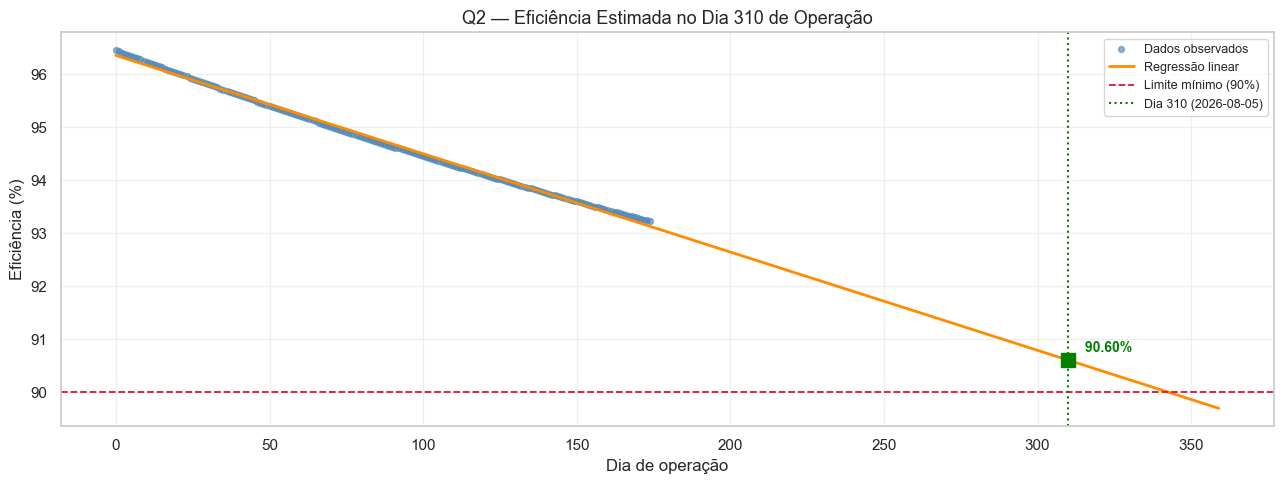

In [12]:
dia_consulta = 310
eff_estimada = modelo(dia_consulta)
data_dia310 = data_inicio + datetime.timedelta(days=dia_consulta)

print('=' * 52)
print('  RESPOSTA — Q2')
print('=' * 52)
print(f'  Dia de operação:         {dia_consulta}')
print(f'  Data correspondente:     {data_dia310.date()}')
print(f'  Eficiência estimada:     {eff_estimada:.4f} %')
print('=' * 52)

# visualização com destaque
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(x, y, color='steelblue', s=18, alpha=0.6, label='Dados observados')
ax.plot(x_ext, y_ext, color='darkorange', linewidth=2, label='Regressão linear')
ax.axhline(90, color='crimson', linestyle='--', linewidth=1.3, label='Limite mínimo (90%)')
ax.axvline(dia_consulta, color='green', linestyle=':', linewidth=1.5,
           label=f'Dia {dia_consulta} ({data_dia310.date()})')
ax.plot(dia_consulta, eff_estimada, 's', color='green', markersize=10, zorder=5)
ax.annotate(f' {eff_estimada:.2f}%',
            xy=(dia_consulta, eff_estimada), xytext=(dia_consulta + 4, eff_estimada + 0.15),
            fontsize=10, color='green', fontweight='bold')

ax.set_title('Q2 — Eficiência Estimada no Dia 310 de Operação', fontsize=13)
ax.set_xlabel('Dia de operação')
ax.set_ylabel('Eficiência (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">6. Conclusão</span>

| Pergunta | Resultado |
|---|---|
| **Q1**: Dia em que a eficiência atinge 90% | **~dia 342** (≈ 06/Set/2026) |
| **Q2**: Eficiência estimada no dia 310 | **≈ 90,60%** (≈ 05/Ago/2026) |

O modelo de regressão linear ajustado com NumPy apresenta alto coeficiente de determinação ($R^2 \approx 0{,}997$), confirmando que o decaimento da eficiência é aproximadamente linear no período analisado.  
Com base no modelo, o equipamento ainda operará **acima do limite de 90%** no dia 310, mas atingirá esse limiar por volta do **dia 342**, indicando que uma intervenção de manutenção preventiva deve ser planejada antes desse ponto.